In [1]:
    %matplotlib inline


Create Plots for Habil
============





In [11]:
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)
import gensim.downloader as api
from gensim.corpora import Dictionary, MmCorpus
import nltk
import pandas as pd
from gensim.models import LdaModel
from gensim.models import EnsembleLda
import string
from sklearn.cluster import KMeans
from sklearn.manifold import Isomap
from scipy.spatial.distance import cdist
import numpy as np
from IPython.core.pylabtools import figsize
import os
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from umap import UMAP
from pathlib import Path
from sklearn.manifold import Isomap
import pickle
import hdbscan
import umap
from adjustText import adjust_text
import plotly
import re
import plotly.express as px
import plotly.io as pio
import matplotlib.patches as mpatches

prefix = "orzeszkowa_eps_0-11_110_10_topics"
text_dir = "literarische_texte"

topic_labels = [
    'Bourgeoisie',
    'Intelligenzija',
    'Aristokratie',
    'Familiäres',
    'Bauern',
    'Christentum',
    'Historisches',
    'Militär',
    'Judentum',
    'Kapital'
]

Load Topic Model
-----------------

In [12]:
ensemble = EnsembleLda.load(prefix + "_model")
dictionary = Dictionary.load(prefix + "_dict")
corpus = MmCorpus(prefix + "_corpus")
with open(prefix + "_titles.txt", "r", encoding="utf-8") as file:
    titles = file.read().split("\n")
with open(prefix + "_chunk_titles.txt", "r", encoding="utf-8") as file:
    chunk_titles = file.read().split("\n")

ensemble.print_topics(60,20)

2026-09-15 23:21:34,925 : INFO : loading EnsembleLda object from orzeszkowa_eps_0-11_110_10_topics_model
2026-09-15 23:21:35,045 : INFO : loading classic_model_representation recursively from orzeszkowa_eps_0-11_110_10_topics_model.classic_model_representation.* with mmap=None
2026-09-15 23:21:35,047 : INFO : loading id2word recursively from orzeszkowa_eps_0-11_110_10_topics_model.classic_model_representation.id2word.* with mmap=None
2026-09-15 23:21:35,047 : INFO : loading state recursively from orzeszkowa_eps_0-11_110_10_topics_model.classic_model_representation.state.* with mmap=None
2026-09-15 23:21:35,048 : INFO : loading ttda from orzeszkowa_eps_0-11_110_10_topics_model.ttda.npy with mmap=None
2026-09-15 23:21:35,083 : INFO : setting ignored attribute topic_model_class to None
2026-09-15 23:21:35,085 : INFO : EnsembleLda lifecycle event {'fname': 'orzeszkowa_eps_0-11_110_10_topics_model', 'datetime': '2026-09-15T23:21:35.085025', 'gensim': '4.4.0', 'python': '3.12.14 (main, Aug 1

[(0,
  '0.000*"salon" + 0.000*"siostra" + 0.000*"hrabia" + 0.000*"las" + 0.000*"ulica" + 0.000*"izba" + 0.000*"ogród" + 0.000*"mama" + 0.000*"koń" + 0.000*"pieniądz" + 0.000*"chata" + 0.000*"sala" + 0.000*"rodzina" + 0.000*"państwo" + 0.000*"towarzystwo" + 0.000*"umysł" + 0.000*"plecy" + 0.000*"muzyka" + 0.000*"krzesło" + 0.000*"interes"'),
 (1,
  '0.108*"doktor" + 0.009*"muzyka" + 0.005*"umysł" + 0.005*"salon" + 0.005*"pacjent" + 0.005*"sztuka" + 0.005*"gabinet" + 0.004*"ulica" + 0.004*"fortepian" + 0.004*"ton" + 0.004*"charakter" + 0.004*"towarzystwo" + 0.004*"przyjaciel" + 0.004*"wesołość" + 0.003*"medycyna" + 0.003*"artysta" + 0.003*"piękność" + 0.003*"zawód" + 0.003*"salonik" + 0.003*"państwo"'),
 (2,
  '0.084*"hrabia" + 0.022*"hrabina" + 0.015*"hrabio" + 0.009*"hrabiy" + 0.007*"rodzina" + 0.005*"pałac" + 0.004*"fotel" + 0.004*"salon" + 0.004*"list" + 0.004*"umysł" + 0.004*"stryj" + 0.003*"państwo" + 0.003*"komnata" + 0.003*"źrenica" + 0.003*"towarzystwo" + 0.003*"wzruszenie" + 0.

Interactive Topic Map
-----------------

In [13]:
# use orginal corpus instead of reuniting chunks
original_corpus = []

for f in sorted(os.listdir(text_dir)):
    with open(os.path.join(text_dir, f)) as fil:
        text = fil.read().split(" ")
        original_corpus.append(dictionary.doc2bow(text))
          
# topic distributions for each document
vecs = np.zeros((len(original_corpus), len(ensemble.get_topics())))
lengths =  []

for i, bow in enumerate(original_corpus):
    lengths.append(len(bow))
    for topic, prob in ensemble[bow]:
        vecs[i, topic] = prob

## Topic distribution for corpus
topic_sums = np.zeros(10)
total_words = 0

for bow in original_corpus:
    doc_length = sum(cnt for _, cnt in bow)
    total_words += doc_length

    for topic, prob in ensemble[bow]:
        topic_sums[topic] += prob * doc_length

corpus_topic_distribution = topic_sums / total_words

# ---- Ranking ----
sorted_indices = np.argsort(-corpus_topic_distribution)
sorted_values = corpus_topic_distribution[sorted_indices]
sorted_labels = [topic_labels[i] for i in sorted_indices]

print("Topic Ranking (Highest → Lowest):\n")
for rank, (label, value) in enumerate(zip(sorted_labels, sorted_values), start=1):
    print(f"{rank}. {label}: {value:.6f}")
      
# get dominant topics
dominant = np.argmax(vecs, axis=1)
vecs_hell = np.sqrt(vecs)
clusters = np.argmax(vecs, axis=1)


coords_file = prefix + "_coords.pkl"

umap_model = umap.UMAP(
    n_neighbors=12,
    min_dist=0.025,
    n_components=2,
    metric="euclidean",  # is Hellinger for vecs_hell = np.sqrt(vecs)
    random_state=42
)
    
coords = umap_model.fit_transform(vecs_hell)

dominant_topics = np.argmax(vecs, axis=1)
fig = px.scatter(x=coords[:,0], y=coords[:,1],  hover_name=titles,color=clusters, size=lengths,  width=1200, height=1000, color_continuous_scale=px.colors.qualitative.Vivid)
pio.renderers.default = "browser"
fig.show()        

Topic Ranking (Highest → Lowest):

1. Aristokratie: 0.177468
2. Bourgeoisie: 0.165631
3. Historisches: 0.151666
4. Bauern: 0.147651
5. Intelligenzija: 0.117257
6. Familiäres: 0.088467
7. Christentum: 0.060484
8. Militär: 0.037148
9. Judentum: 0.026613
10. Kapital: 0.021272


/home/ghowa/.venv/lib64/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Print-Ready Map
-----------------

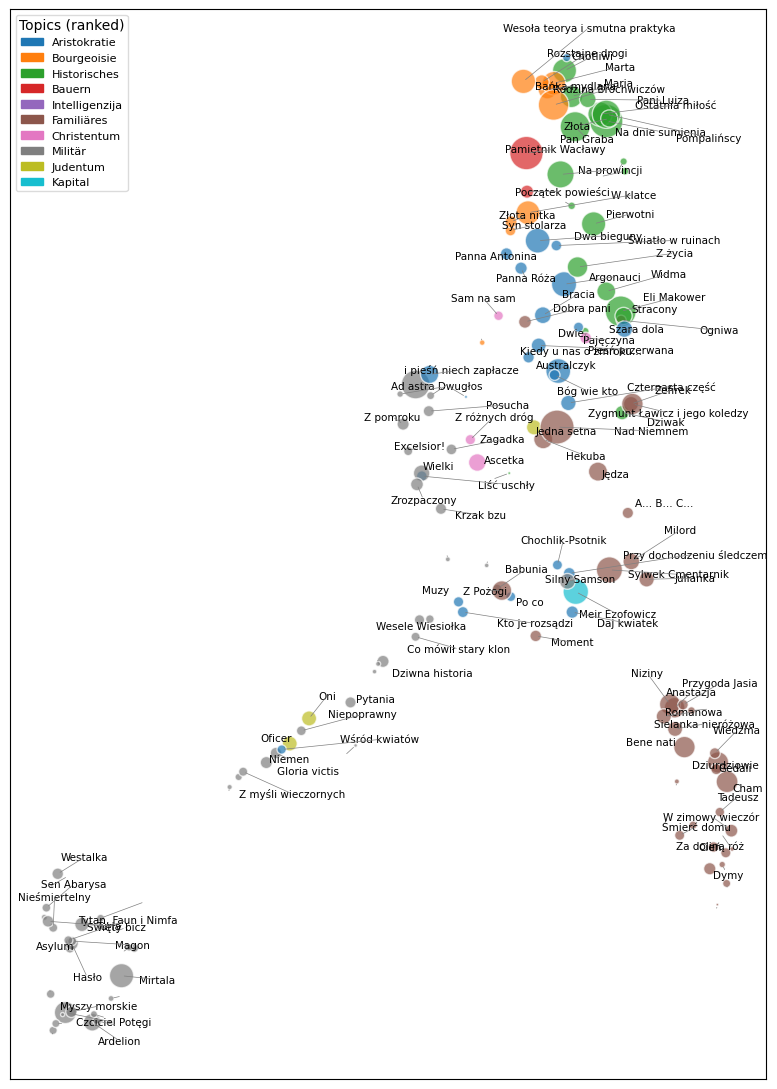

In [17]:
# --- Plot for print using matplotlib + adjustText ---
plt.figure(figsize=(8, 11))
scatter = plt.scatter(
    coords[:, 0], coords[:, 1],
    c=clusters,             # color by dominant topic,
    cmap=plt.get_cmap('tab10'),            # up to 20 topics
    s=[len(b)/10 for b in original_corpus],#np.clip(np.array([len(b) for b in original_corpus]), 5, 100),  # size proportional to doc length
    alpha=0.7,
    edgecolors='white'
)

# Annotate points with titles (abbreviated for readability)
labels = []
for i, title in enumerate(titles):
    if len(original_corpus[i]) >= 400:
        labels.append(title)  # show label
    else:
        labels.append("")     # empty string → no label

texts = []
for i, title in enumerate(labels):
    # Abbreviate long titles for print
    short_title = " ".join(title.split("_")[:-2])
    texts.append(plt.text(coords[i, 0], coords[i, 1], short_title, fontsize=7.5))

# Adjust text labels to prevent overlap
adjust_text(
    texts, 
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    expand_text=(1.2, 1.2),   # push labels further apart
    expand_points=(1.2, 1.2),
    force_text=0.5,
    force_points=0.5
)

# Remove ticks
ax = plt.gca()
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Add top-left legend
cmap = plt.get_cmap('tab10')
num_topics = len(np.unique(clusters))

handles = [mpatches.Patch(color=cmap(i), label=topic_labels[i]) for i in range(num_topics)]
plt.legend(handles=handles, loc='upper left', fontsize=8, framealpha=0.7, borderpad=0.3)

# sort topics by descending corpus weight
sorted_indices = np.argsort(corpus_topic_distribution)[::-1]

handles = []
for new_rank, topic_index in enumerate(sorted_indices):
    handles.append(
        mpatches.Patch(
            color=cmap(topic_index),        # keep original cluster color
            label=topic_labels[topic_index] # but show in sorted order
        )
    )

plt.legend(
    handles=handles,
    loc='upper left',
    fontsize=8,
    framealpha=0.7,
    borderpad=0.3,
    title="Topics (ranked)"
)

plt.tight_layout()
plt.savefig(prefix+"_umap_print.pdf", format="pdf", bbox_inches="tight")
plt.show()

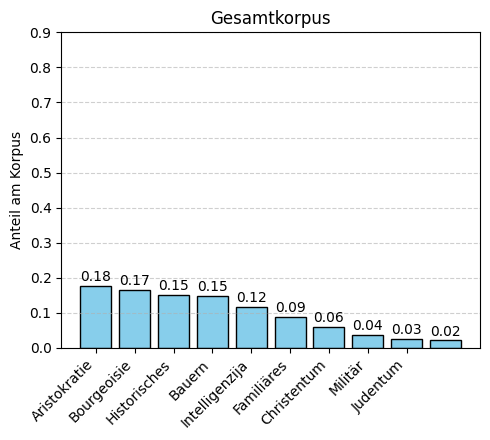

In [19]:
# ---- Plot ----
#plt.figure(figsize=(10,6.5))
plt.figure(figsize=(5,4.5))
plt.bar(range(len(sorted_values)), sorted_values, color="skyblue", edgecolor="black")
plt.title("Gesamtkorpus")

plt.ylabel("Anteil am Korpus")
plt.xticks(range(len(sorted_labels)), sorted_labels, rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, 0.9)

# Optional: show values on top of bars
for i, val in enumerate(sorted_values):
    plt.text(i, val + 0.005, f"{val:.2f}", ha="center", va="bottom")
# sort topics by descending corpus weight
sorted_indices = np.argsort(corpus_topic_distribution)[::-1]

handles = []
for new_rank, topic_index in enumerate(sorted_indices):
    handles.append(
        mpatches.Patch(
            color=cmap(topic_index),        # keep original cluster color
            label=topic_labels[topic_index] # but show in sorted order
        )
    )


plt.tight_layout()
plt.savefig(prefix + "_corpus_topics.pdf", format="pdf", bbox_inches="tight")
plt.show()

Topic Ranking (Highest → Lowest):

1. Aristokratie: 0.392430
2. Bourgeoisie: 0.138340
3. Historisches: 0.096791
4. Bauern: 0.000000
5. Intelligenzija: 0.137747
6. Familiäres: 0.120187
7. Christentum: 0.040921
8. Militär: 0.041624
9. Judentum: 0.012270


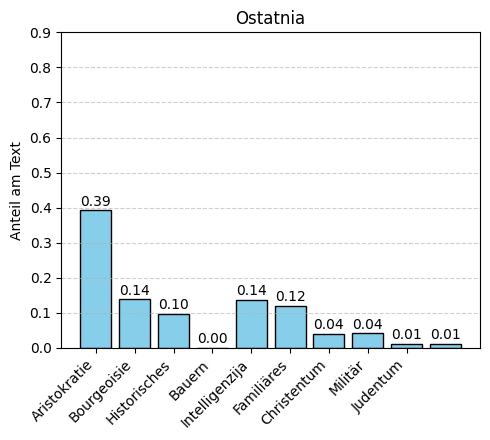

In [20]:
# top topics for one document
title = "Ostatnia"

for i in range(len(titles)):
    if titles[i].startswith(title):
        topic_probs = vecs[i]

# ---- Ranking ----
#sorted_indices = np.argsort(-topic_probs)
sorted_values = topic_probs[sorted_indices]
#sorted_labels = [topic_labels[i] for i in sorted_indices]

print("Topic Ranking (Highest → Lowest):\n")
for rank, (label, value) in enumerate(zip(sorted_labels, sorted_values), start=1):
    print(f"{rank}. {label}: {value:.6f}")

# ---- Plot ----
plt.figure(figsize=(5,4.5))
plt.bar(range(len(sorted_values)), sorted_values, color="skyblue", edgecolor="black")

plt.title(re.sub("_", " ", title))
plt.ylabel("Anteil am Text")
plt.xticks(range(len(sorted_labels)), sorted_labels, rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, 0.9)

# Optional: show values on top of bars
for i, val in enumerate(sorted_values):
    plt.text(i, val + 0.005, f"{val:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(prefix + "_" + title +"_topics.pdf", format="pdf", bbox_inches="tight")
plt.show()

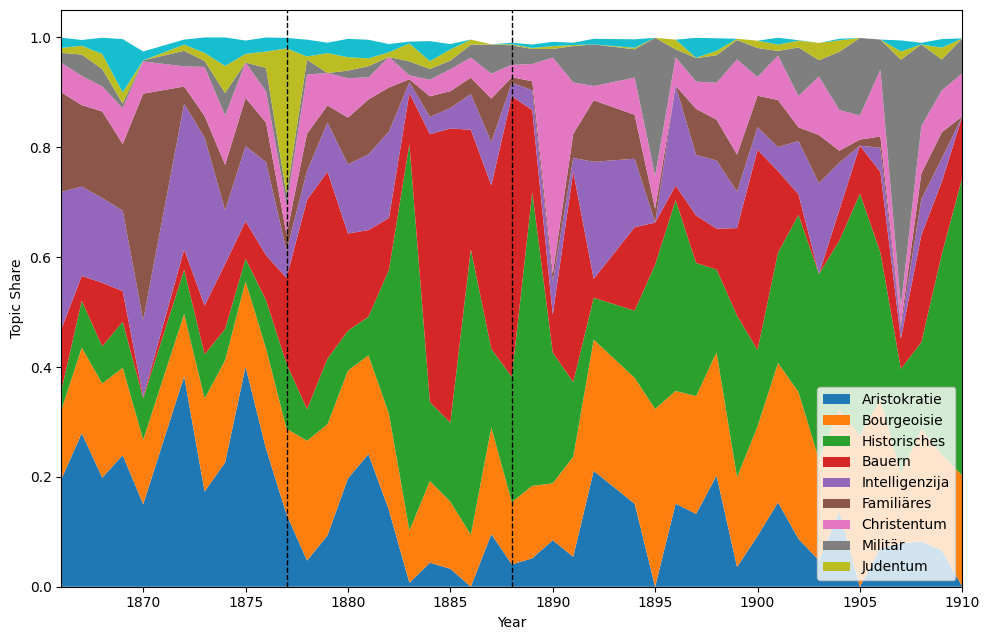

In [21]:
# continuous topic dist
from collections import defaultdict
import numpy as np

n_topics = 10

year_topic_sums = defaultdict(lambda: np.zeros(n_topics))
year_word_totals = defaultdict(int)


years = []

for title in titles:
    match = re.search(r"_(\d{4})", title)
    if match:
        years.append(int(match.group(1)))
    else:
        years.append(None)

for i, bow in enumerate(original_corpus):
    year = years[i]
    if year is None:
        continue

    doc_length = sum(cnt for _, cnt in bow)
    year_word_totals[year] += doc_length

    for topic, prob in ensemble[bow]:
        year_topic_sums[year][topic] += prob * doc_length

year_distributions = {}

for year in year_topic_sums:
    year_distributions[year] = (
        year_topic_sums[year] / year_word_totals[year]
    )

sorted_years = sorted(year_distributions.keys())

topic_matrix = np.array(
    [year_distributions[y] for y in sorted_years]
).T

topic_matrix = topic_matrix[sorted_indices]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6.5))

plt.stackplot(
    sorted_years,
    topic_matrix,
    labels=sorted_labels
)

plt.xlabel("Year")
plt.ylabel("Topic Share")
plt.legend(loc="lower right") #, bbox_to_anchor=(1,1))
plt.axvline(x=1877, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1888, color="black", linestyle="--", linewidth=1)
plt.xlim(1866, 1910)

plt.tight_layout()
plt.show()

/tmp/ipykernel_477389/2868841800.py:18: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



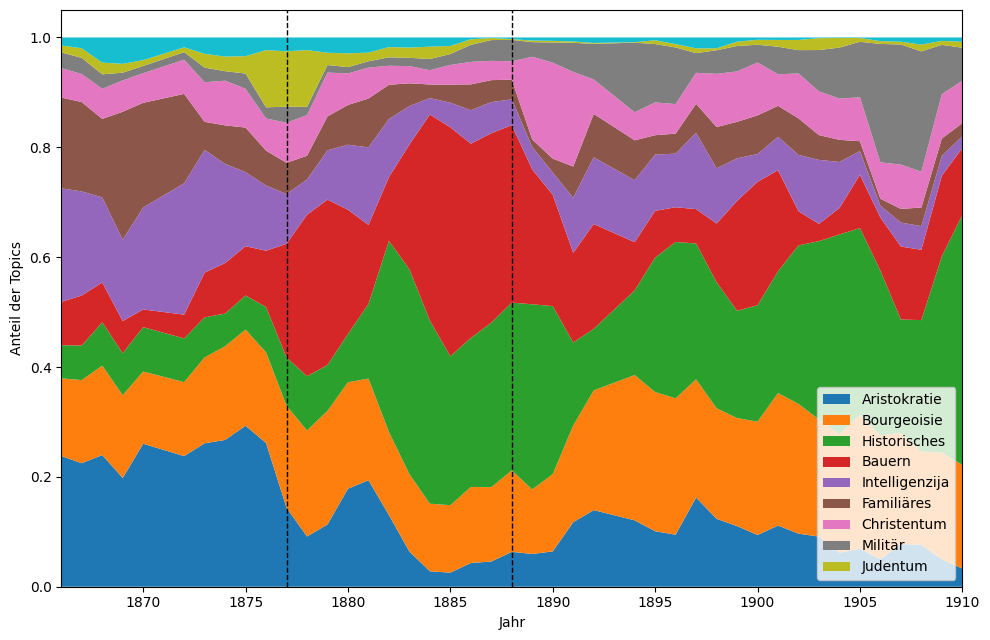

In [22]:
# smooth plot
import pandas as pd

df = pd.DataFrame(topic_matrix.T, index=sorted_years)

df_smooth = df.rolling(window=3, center=True, min_periods=1).mean()

topic_matrix_smooth = df_smooth.values.T

# Renormalize (important!)
topic_matrix_smooth = topic_matrix_smooth / topic_matrix_smooth.sum(axis=0)


plt.figure(figsize=(10,6.5))

from matplotlib.cm import get_cmap

cmap = get_cmap("tab20")  # good for up to 20 topics
colors = [cmap(i) for i in range(len(sorted_labels))]

plt.stackplot(
    sorted_years,
    topic_matrix_smooth,
    labels=sorted_labels,
)

plt.axvline(x=1877, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1888, color="black", linestyle="--", linewidth=1)

plt.xlabel("Jahr")
plt.ylabel("Anteil der Topics")
plt.legend(loc="lower right") #, bbox_to_anchor=(1,1))
plt.xlim(1866, 1910)


# Optional: light grid
ax.grid(axis="y", linewidth=0.3, alpha=0.4)

plt.tight_layout()
#plt.savefig(prefix + "_corpus_topics_share.png", dpi=600)
plt.savefig("topics_share.pdf", format="pdf", bbox_inches="tight")
plt.show()

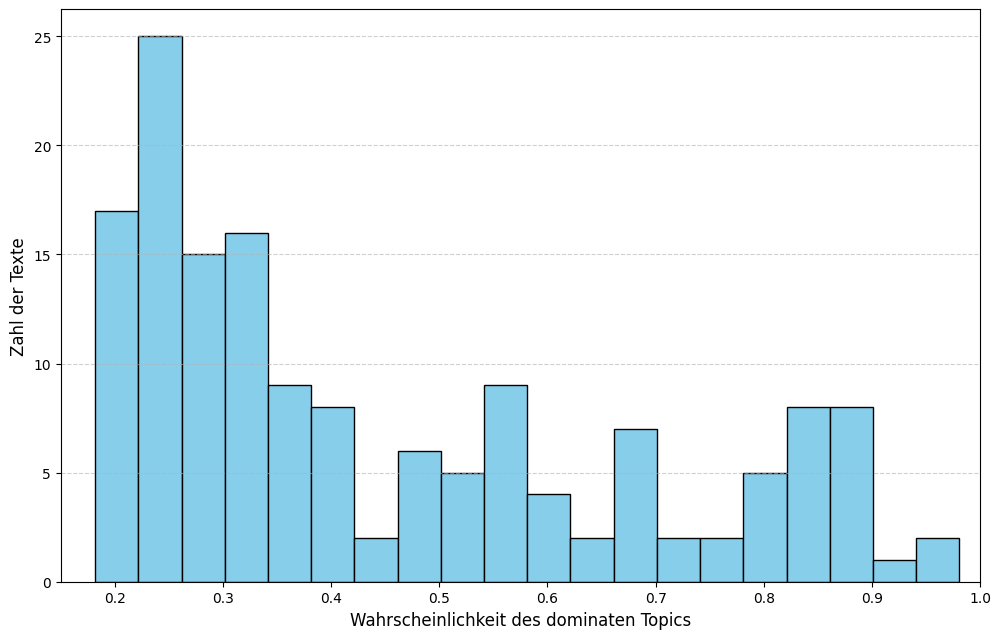

In [23]:
# dominant topics histo
import matplotlib.pyplot as plt

# dominant topic probability per text
dominant_probs = np.max(vecs, axis=1)

plt.figure(figsize=(10,6.5))
plt.hist(dominant_probs, bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Wahrscheinlichkeit des dominaten Topics", fontsize=12)
plt.ylabel("Zahl der Texte", fontsize=12)
#plt.title("Monothematicity of Texts in Corpus", fontsize=14)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.yticks(fontsize=10)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xlim(0.15, 1)
plt.savefig(prefix + "_dominant_topic_hist.pdf", format="pdf", bbox_inches="tight")
plt.show()